In [1]:
from tensorflow import keras
from tensorflow.keras import layers

###(1) Residual connections
The residual connections act as an information shortcut around destructive or noisy blocks (such as blocks that contain relu activation or dropoutslayers), enabling error gradient information from early layers to propagate noiselessly through the deep network. so the last layer contain not just the processes information through the layers but also the original information of the input layer.

lets look at an example of simple convnet structured into series of blocks, each made of two convolution layers and one optional max pooling with a residual connection around each block.

In [2]:
inputs = keras.Input(shape=(32, 32, 3))
x = layers.Rescaling(1./255)(inputs)

#utility function below to apply a convolutional block with a residual connection with an option to add max pooling
def residual_block(x, filters, pooling=False):
    residual = x
    x = layers.Conv2D(filters, 3, activation='relu', padding='same')(x)
    x = layers.Conv2D(filters, 3, activation='relu', padding='same')(x)

    if pooling:
      x = layers.MaxPooling2D(2, padding='same')(x)
      residual = layers.Conv2D(filters, 1, strides=2)(residual) # if we use maxpooling, we add a strided convolution to..
                                                                #.. project the residual to the expected shape.
    elif filters != residual.shape[-1]:
      residual = layers.Conv2D(filters, 1)(residual)  #if we don't use max pooling, we only project the residuals if the..
                                                      #..number of channels has changed
    x = layers.add([x, residual])
    return x

In [3]:
x = residual_block(x, filters=32, pooling=True)  # first block
x = residual_block(x, filters=64, pooling=True)  # second block; note the increasing filter count in each  block
x = residual_block(x, filters=128, pooling=True) # last block does'nt need a max pooling layer since we will apply global..
                                                #..average pooling right after it.
x = layers.GlobalAveragePooling2D()(x)          # This computes the average of all the channels, instead of just flattening it.
output = layers.Dense(1, activation='sigmoid')(x)
model = keras.Model(inputs=inputs, outputs=output)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 32, 32, 3) │          0 │ input_layer[0][0] │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │        896 │ rescaling[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 16, 16,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │        128 │ rescaling[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 16, 16,    │          0 │ max_pooling2d[0]… │
│                     │ 32)               │            │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 16,    │     18,496 │ add[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 16,    │     36,928 │ conv2d_3[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 8, 8, 64)  │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 8, 8, 64)  │      2,112 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 8, 8, 64)  │          0 │ max_pooling2d_1[… │
│                     │                   │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 8, 8, 128) │     73,856 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 8, 8, 128) │    147,584 │ conv2d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 4, 4, 128) │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 4, 4, 128) │      8,320 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 4, 4, 128) │          0 │ max_pooling2d_2[… │
│                     │                   │            │ conv2d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ add_2[0][0]       │
│ (GlobalAveragePool… │                   │            │                 

 Total params: 297,697 (1.14 MB)

 Trainable params: 297,697 (1.14 MB)

 Non-trainable params: 0 (0.00 B)

###(2) Batch Normalization
Normalization is a broad category of methods that seek to make different samples seen by a machine learning model more similar to each other, which helps th model learn and generalize well to new data.
 a) Batch  Normalization: is a type of layer that can adaptively normalize data even as the mean and variance change over time during training. This makes sure that the data entering any layer is duely normalized.

 Batch normalization, just as residual connections helps with gradient propagation, and thus allows for deeper networks. It can be used after any layer - Dense, Conv2D etc. :

In [4]:
input_layer = layers.Input(shape=(32, 32, 3))
x = layers.Conv2D(32, 3, use_bias=False)(input_layer)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)

It is recommended to use the activation after the BatchNormalization, like the following:


In [5]:
x = layers.Conv2D(32, 3,use_bias=False)(input_layer)  # NOte the lack of activation here
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)   # Activation is placed after the normalization layer

Its worth noting that when using batch normalization, there is no need for using bias as seen from the previous example (where use_bias = False), this is because the normalization takes care of centering the layers output on zero.

### (3) Depthwise seperable convolutions

A layer you can use a a drop-in replacement for Conv2D that wil make your model smaller (fewer trainable weights parameters) and leaner (fewer floating-point operations), and cause it to perform a few percentage points better on its task - This is what the depthwise seperabel convolution layer does.

The layer performs a spatial convolutions on each channel of its input, independently, before mixing output channels via a pointwise convolution (a 1 * 1 convolution).

### A mini Xception-like model

we will bring all these ideas together into a single model and apply it to the previous Cat vs Dog task from the last chapter.  lets load the data using the same setup we used in the previous task.

However, we will replace the previous model architecture with our own.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import json, os, shutil, pathlib

In [8]:
files = os.listdir("/content/drive/MyDrive/train")
print(len(files))

8005


In [9]:
original_dir = pathlib.Path("/content/drive/MyDrive/train")  #path to the directory where the original data was uncompressed.
new_base_dir = pathlib.Path("/content/drive/MyDrive/cats_vs_dogs_small") # directory where we will store our smaller dataset.

In [10]:
from tensorflow.keras.utils import image_dataset_from_directory

In [11]:
print(len(os.listdir("/content/drive/MyDrive/cats_vs_dogs_small/train/cat")))  # to inspect our data

1000


In [12]:
train_dataset = image_dataset_from_directory(
    new_base_dir / "train",
    image_size=(180, 180),
    batch_size=32
)
validation_dataset = image_dataset_from_directory(
    new_base_dir / "validation",
    image_size=(180, 180),
    batch_size=32
)
test_dataset = image_dataset_from_directory(
    new_base_dir / "test",
    image_size=(180, 180),
    batch_size=32
)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.


Now,  lets define our own model architecture:

First we configure the data augmentation, same as the example under convnet

In [13]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),  # horizontal flipping to a random 50% of the images that goes through it.
    layers.RandomRotation(0.1),  # rotates the input images by a random value to a range of [-10%, +10%] of 360%
    layers.RandomZoom(0.2)   # zooms in/out of the image by a random factor in the range[-20%, +20%].
])

In [14]:
inputs = keras.Input(shape=(180,180,3))
x = data_augmentation(inputs)

x = layers.Rescaling(1./255)(x)
x = layers.Conv2D(filters=32, kernel_size=5, use_bias=False)(x)

for size in [32, 64, 128, 256, 512]:   # we apply a series of convolutional blocks with increasing future depth.each block consist of..
  residual = x                         #..two batch-normalized depthwise seperable convolution layers and a max pooling layer, with a ..
                                       #.. residual connection around the entire block.
  x = layers.BatchNormalization()(x)
  x = layers.Activation("relu")(x)
  x = layers.SeparableConv2D(size, 3, padding="same", use_bias=False)(x)

  x = layers.BatchNormalization()(x)
  x = layers.Activation("relu")(x)
  x = layers.SeparableConv2D(size, 3, padding="same", use_bias=False)(x)

  x = layers.MaxPooling2D(3, strides=2, padding="same")(x)

  residual = layers.Conv2D(size, 1, strides=2, padding="same", use_bias=False)(residual)
  x = layers.add([x, residual])

x = layers.GlobalAveragePooling2D()(x)     # here unlike the original model, we use GlobalAveragePooling2D, not flatten.
x = layers.Dropout(0.5)(x)                          # we add a dropout layer for regularization, same as the previous one.
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

If you notice closely, the first layer of our model is a reg Conv2D layer. This is because the assumption of Seperable convolutions is that the feature channels are largely independent. This is however not true to RBG channels: they are highly correlated. so we use a normal convolution at first, and begin using seperable convolutions afterwards.

In [15]:
model.compile(loss='binary_crossentropy',
              optimizer='rmsprop',
              metrics=['accuracy'])

Now we train our model:

In [25]:
callbacks = [keras.callbacks.ModelCheckpoint(
     filepath="convnet_from_scratch_with_augmentation.keras",
     save_best_only=True,
     monitor="val_loss"
 )]

sep_conv_history = model.fit(train_dataset, epochs=100,
                     validation_data=validation_dataset,
                     callbacks=callbacks)

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1256s 20s/step - accuracy: 0.5515 - loss: 0.7278 - val_accuracy: 0.5290 - val_loss: 0.6915
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 243ms/step - accuracy: 0.6118 - loss: 0.6603 - val_accuracy: 0.5000 - val_loss: 0.6933
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 245ms/step - accuracy: 0.6282 - loss: 0.6446 - val_accuracy: 0.5000 - val_loss: 0.6977
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 234ms/step - accuracy: 0.6394 - loss: 0.6423 - val_accuracy: 0.5000 - val_loss: 0.7442
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 235ms/step - accuracy: 0.6661 - loss: 0.6190 - val_accuracy: 0.5000 - val_loss: 0.8261
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 235ms/step - accuracy: 0.6816 - loss: 0.6173 - val_accuracy: 0.5000 - val_loss: 1.0152
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 238ms/step - accuracy: 0.6580 - loss: 0.6186 - val_accuracy: 0.5040 - val_loss: 0.7420
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 234ms/step - accuracy: 0.6647 - loss: 0.6102 - 

In [26]:
import numpy as np

In [27]:
model.save("/content/drive/MyDrive/cats_vs_dogs_original/separable_conv2D.keras")
np.save("/content/drive/MyDrive/cats_vs_dogs_original/sep_conv_history.npy", sep_conv_history.history)

In [28]:
import matplotlib.pyplot as plt

In [29]:
history = np.load("/content/drive/MyDrive/cats_vs_dogs_original/sep_conv_history.npy",
    allow_pickle=True
).item()

In [30]:
history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

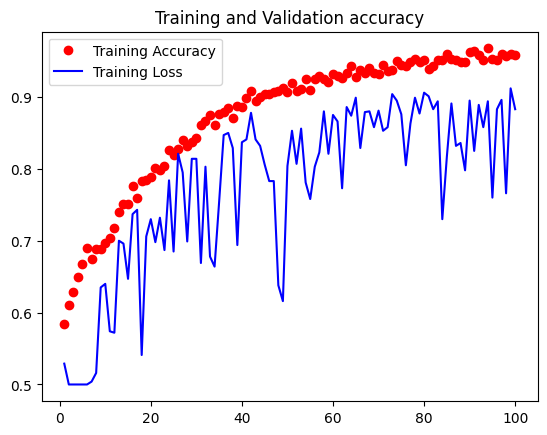

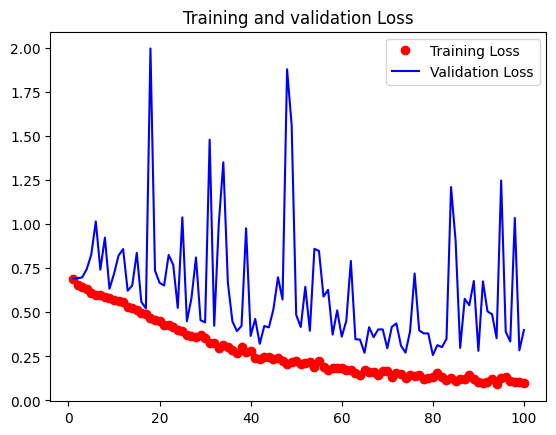

In [31]:
accuracy = history["accuracy"]
val_accuracy = history["val_accuracy"]
loss = history["loss"]
val_loss = history["val_loss"]
epochs = range(1,  len(accuracy) + 1)

plt.plot(epochs, accuracy, "ro", label="Training Accuracy")
plt.plot(epochs, val_accuracy, "b", label="Training Loss")
plt.title('Training and Validation accuracy')
plt.legend()
plt.figure()

plt.plot(epochs, loss, 'ro', label="Training Loss")
plt.plot(epochs, val_loss, "b", label="Validation Loss")
plt.title("Training and validation Loss")
plt.legend()
plt.show()

Now lets check our test accuracy:

In [32]:
test_model = keras.models.load_model("/content/drive/MyDrive/cats_vs_dogs_original/separable_conv2D.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - accuracy: 0.8637 - loss: 0.4566
Test accuracy: 0.8569999933242798
